In [136]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import tensorflow as tf
from numpy.ma.core import shape

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
import sklearn
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [137]:
from tensorflow import keras
from tensorflow.keras import layers


def build_lstm_autoencoder(
    timesteps: int,
    n_features: int,
    latent_dim: int = 32,
    encoder_units: list[int] = (128, 64),
    decoder_units: list[int] = None,
    activation: str = "tanh",
    dropout: float = 0.0,
    optimizer: str = "adam",
    loss: str = "mse",
) -> keras.Model:
    if decoder_units is None:
        decoder_units = list(reversed(encoder_units))

    inputs = keras.Input(shape=(timesteps, n_features))

    x = inputs
    for units in encoder_units:
        x = layers.LSTM(units, activation=activation, return_sequences=True, dropout=dropout)(x)
    encoded = layers.LSTM(latent_dim, activation=activation, return_sequences=False,
                           dropout=dropout, name="bottleneck")(x)

    x = layers.RepeatVector(timesteps)(encoded)
    for units in decoder_units:
        x = layers.LSTM(units, activation=activation, return_sequences=True, dropout=dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

    autoencoder = keras.Model(inputs, outputs, name="lstm_autoencoder")
    encoder = keras.Model(inputs, encoded, name="lstm_encoder")
    autoencoder.compile(optimizer=optimizer, loss=loss)
    return autoencoder, encoder

In [138]:
TIME_STEP = 10
SAMPLE_AGGREGATION_RATE = 20
SD_DEVIATION_THRESHOLD = 1

In [139]:
## Load and scale raw data
door_events = pd.read_pickle("door_events.pkl")

# Normalise data with non-anomalous points only
normal_mask = door_events["label"] == 0

features = door_events.iloc[:,9:25]
normal_X = features[normal_mask]
scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(normal_X) # Only fit to normal points
trf_X = pd.DataFrame(scaler.transform(features)) # Transform all points

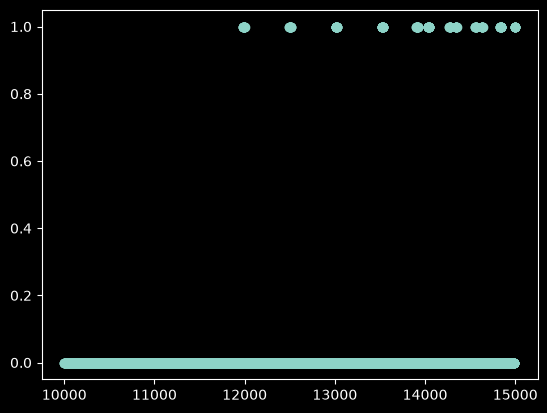

In [140]:
start, end = 10000, 15000
plot_x_values = [i for i in range(start, end)]
plt.scatter(plot_x_values, door_events["label"][start:end])

In [141]:
from numpy.lib.stride_tricks import sliding_window_view

### Create time step windows
def make_windows(df, window_size):
    # Convert DataFrame to a contiguous NumPy array
    data = df.to_numpy()

    # Generate 3D sliding window view: shape -> (N_windows, window_size, features)
    windows = sliding_window_view(data, window_shape=window_size, axis=0)

    # Transpose dimensions so shape is (N_windows, window_size, features)
    return windows

### Resample training data
sampled_X = trf_X.groupby(trf_X.index // SAMPLE_AGGREGATION_RATE).mean()
window_X = make_windows(sampled_X, TIME_STEP).transpose((0, 2, 1))
print(f"window_X shape: {window_X.shape}")
assert window_X.shape[1] == TIME_STEP

### Resample labels
resampled_labels = door_events["label"].groupby(door_events.index // SAMPLE_AGGREGATION_RATE).max()
window_y = make_windows(resampled_labels, TIME_STEP)[:,-1]
print(f"window_y shape: {window_y.shape}")

### Separate normal and anomalous windows
normal_window_mask = window_y == 0
normal_window_X = window_X[normal_window_mask]
anomalous_window_X = window_X[~normal_window_mask]


window_X shape: (1337, 10, 16)
window_y shape: (1337,)


In [142]:
### Build and fit autoencoder
autoencoder, encoder = build_lstm_autoencoder(TIME_STEP, 16)

train_X, test_normal_X = train_test_split(normal_window_X, test_size=0.2, shuffle=True, random_state=42)
fit_X, val_X = train_test_split(train_X, test_size=0.2, shuffle=True, random_state=42)

autoencoder.fit(fit_X, fit_X, validation_data=(val_X,val_X), epochs=70)

Epoch 1/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 1.2929 - val_loss: 1.2766
Epoch 2/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.1669 - val_loss: 1.1984
Epoch 3/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.0816 - val_loss: 1.1050
Epoch 4/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.0190 - val_loss: 1.0695
Epoch 5/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9689 - val_loss: 0.9922
Epoch 6/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.9357 - val_loss: 0.9878
Epoch 7/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.8722 - val_loss: 0.9407
Epoch 8/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8357 - val_loss: 0.9038
Epoch 9/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.8435 - val_loss: 0.8620
Epoch 10/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.7920 - val_loss: 0.8489
Epoch 11/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7716 - val_loss: 0.8186
Epoch 12/70
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.7

In [160]:
### Split test data into tuning and final testing sets
tuning_normal_X, eval_normal_X = train_test_split(test_normal_X, test_size=0.5, random_state=42)
tuning_anomalous_X, eval_anomalous_X = train_test_split(anomalous_window_X, test_size=0.5, random_state=42)

tuning_X = np.concat([tuning_normal_X, tuning_anomalous_X])
tuning_y = np.concatenate([
    np.zeros(len(tuning_normal_X)),
    np.ones(len(tuning_anomalous_X)),
])

eval_X = np.concat([eval_normal_X, eval_anomalous_X])
eval_y = np.concatenate([
    np.zeros(len(eval_normal_X)),
    np.ones(len(eval_anomalous_X)),
])

### Run prediction with autoencoder on tuning set only
def run_model_get_mse(X):
    pred_X = autoencoder.predict(X)
    mses = []
    for i in range(len(pred_X)):
        mses.append(sklearn.metrics.mean_squared_error(X[i], pred_X[i]))
    return mses

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
237


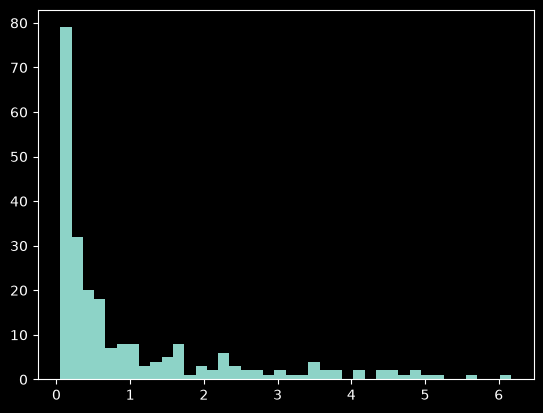

In [161]:
# Compute MSEs
tuning_mses = run_model_get_mse(tuning_X)

plt.hist(tuning_mses, bins=40)
print(len(tuning_mses))

In [155]:
# Identify anomalies
def tune_model_with_percentile(cutoff_percentile):
    threshold = np.percentile(tuning_mses, cutoff_percentile)
    y_pred = []
    for i in range(len(tuning_mses)):
        if tuning_mses[i] >= threshold:
            y_pred.append(1)
        else:
            y_pred.append(0)

    # Assess performance
    cm = sklearn.metrics.confusion_matrix(tuning_y, y_pred)

    precision = sklearn.metrics.precision_score(tuning_y, y_pred)
    recall = sklearn.metrics.recall_score(tuning_y, y_pred)
    f1 = sklearn.metrics.f1_score(tuning_y, y_pred)
    #print(f"Precision = {round(precision,3)}, Recall = {round(recall,3)}, F1-Score = {round(f1,3)}")
    return f1


In [169]:
### Tune cutoff point for F1
cutoffs = [i/2 for i in range(0, 2*100)]
f1_scores = []

for cutoff in cutoffs:
    f1_scores.append(tune_model_with_percentile(cutoff))

best_cutoff = cutoffs[f1_scores.index(max(f1_scores))]
best_threshold = np.percentile(tuning_mses, best_cutoff)

In [170]:
### Run model with best cutoff
eval_mses = run_model_get_mse(eval_X)
pred_eval_y = [int(mse > best_threshold) for mse in eval_mses]

f1 = sklearn.metrics.f1_score(eval_y, pred_eval_y)
print(f"Evaluation F1 score = {f1}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Evaluation F1 score = 0.823943661971831
